In [1]:
from pathlib import Path
import sys, os
import numpy as np

PYLIANS_LIBRARY = Path.home() / 'Pylians3' / 'library'
sys.path.insert(0, str(PYLIANS_LIBRARY))

import readfof
from scipy.spatial import Delaunay

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.collections import LineCollection

matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
os.environ['PATH'] = '/Library/TeX/texbin:' + os.environ['PATH']
plt.style.use('dark_background')

In [6]:
cat_dir = (Path.home() / 'Desktop' / 'Quijotes' / 'data' / 'Om_m' / '0')
cat_dir

PosixPath('/Users/valeriatorresgomez/Desktop/Quijotes/data/Om_m/0')

In [7]:
snapnum = 3
redshift = 0.5

In [8]:
fof = readfof.FoF_catalog(str(cat_dir),
                          snapnum,
                          long_ids=False,
                          swap=False,
                          SFR=False,
                          read_IDs=False)
fof

In [9]:
positions = fof.GroupPos / 1e3
masses = fof.GroupMass * 1e10
velocities = fof.GroupVel * (1.0 + redshift)
n_particles = fof.GroupLen

In [10]:
print(f'num halos: {len(masses):,}')
print(f'shape pos: {positions.shape}')
print(f'range X: {positions[:, 0].min():.3f} -- {positions[:, 0].max():.3f} Mpc/h')
print(f'min mass: {masses.min():.3e} Msun/h')
print(f'max mass: {masses.max():.3e} Msun/h')
print(f'part per halo: {n_particles.min()} -- {n_particles.max()}')

num halos: 306,082
shape pos: (306082, 3)
range X: 0.001 -- 999.998 Mpc/h
min mass: 1.272e+13 Msun/h
max mass: 2.051e+15 Msun/h
part per halo: 20 -- 3226


In [11]:
positions

array([[686.0404  , 533.57715 , 426.41452 ],
       [180.57701 , 779.80475 , 774.30066 ],
       [988.39874 , 204.7962  , 305.85986 ],
       ...,
       [987.97546 , 958.9545  , 922.5841  ],
       [997.7891  , 933.4853  , 934.0105  ],
       [  4.458112, 982.4537  , 903.51324 ]],
      shape=(306082, 3), dtype=float32)

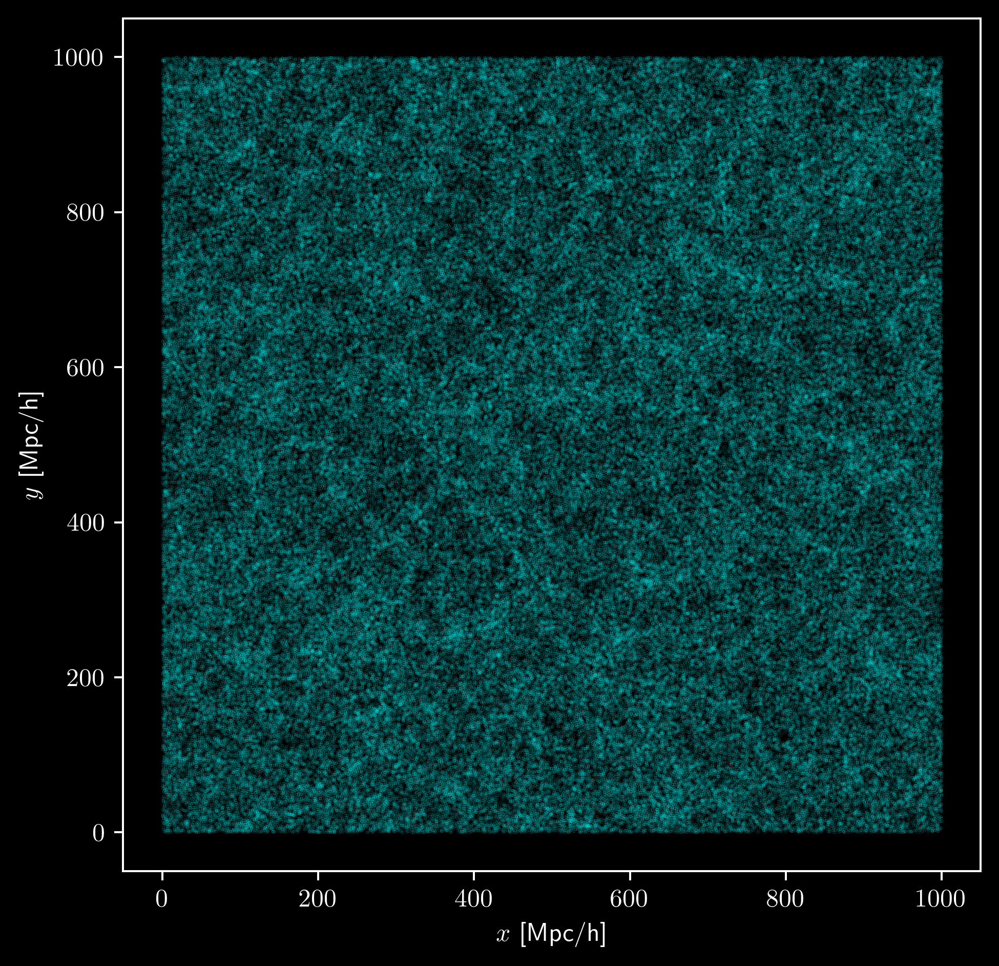

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(positions[:, 0], positions[:, 1], s=0.01, alpha=0.3, color='cyan')
ax.set_xlabel(r'$x$ [Mpc/h]')
ax.set_ylabel(r'$y$ [Mpc/h]')
plt.show()

In [14]:
box_size = 1000.0
n_random = len(masses)

In [15]:
rng = np.random.default_rng(seed=42)

rand_cat = rng.uniform(low=0.0, high=box_size,
                               size=(n_random, 3))
rand_cat.shape

(306082, 3)

In [16]:
rand_cat.shape, positions.shape

((306082, 3), (306082, 3))

In [17]:
cat = np.concatenate((positions, rand_cat), axis=0)
cat.shape

(612164, 3)

In [18]:
tri = Delaunay(cat)
tri

In [19]:
edge_pairs = np.array([[0, 1], [0, 2],
                      [0, 3], [1, 2],
                      [1, 3], [2, 3],])

edges = tri.simplices[:, edge_pairs].reshape(-1, 2)

edges = np.sort(edges, axis=1)
edges = np.unique(edges, axis=0)

segments = cat[edges][:, :, :2]

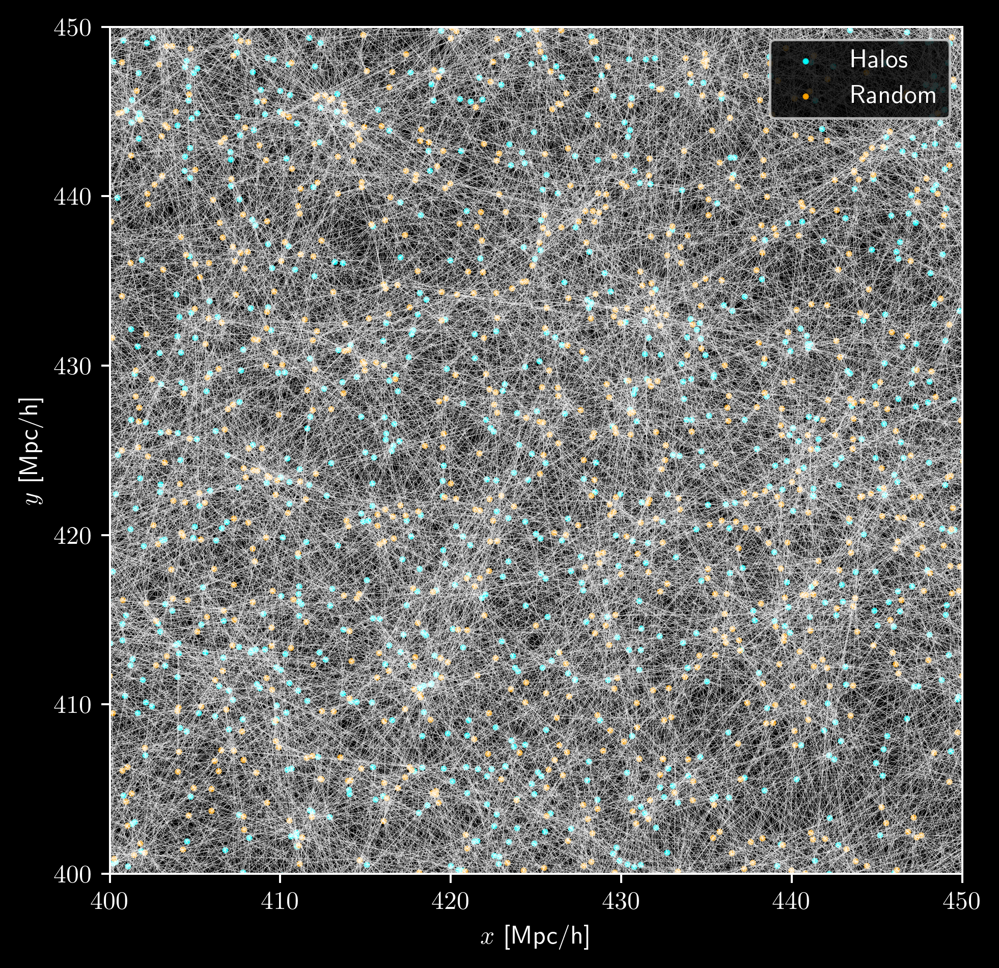

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(positions[:, 0], positions[:, 1], s=2., alpha=0.9, color='cyan',
           label='Halos')
ax.scatter(rand_cat[:, 0], rand_cat[:, 1], s=2., alpha=0.9, color='orange',
           label='Random')

lines = LineCollection(segments, colors='white', linewidths=0.1, alpha=0.8)
ax.add_collection(lines)

ax.set_xlabel(r'$x$ [Mpc/h]')
ax.set_ylabel(r'$y$ [Mpc/h]')

ax.set_xlim(400,450)
ax.set_ylim(400,450)

plt.legend(loc='upper right',)

plt.show()

In [22]:
edges

array([[     0,   1431],
       [     0,   5411],
       [     0, 108499],
       ...,
       [611646, 612016],
       [611772, 611924],
       [611871, 612009]], shape=(4725180, 2), dtype=int32)